13. Исследование длины и ширины 139 черепов, найденных в Верхнем Египте и относимых к расе, жившей за 8000 лет до нашей эры, показало, что стандартное отклонение длины и ширины черепа 5,722 и 4,612 мм соответственно. Те же величины, выведенные на основании обследования 1000 европейцев, оказались равными 6,161 и 5,055 мм. Предполагая, что законы распределения длины и ширины черепа нормальные, выяснить, можно ли считать расхождение стандартов случайным. Построить график мощности критерия.

In [1]:
#Подключаем нужные библиотеки
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [4]:
alpha = 0.05
n = 139
m = 1000

Sx_length, Sy_length = 5.722, 6.161
Sx_width, Sy_width = 4.612, 5.055

In [5]:
quantil_a_popolam = stats.f.ppf(alpha / 2, n - 1, m - 1)
quantil_1_minus_a_popolam = stats.f.ppf(1 - alpha / 2, n - 1, m - 1)

print(f"Квантиль порядка α/2: {quantil_a_popolam};\nКвантиль порядка 1 - α/2: {quantil_1_minus_a_popolam}")

delta_length = Sx_length ** 2 / Sy_length ** 2
delta_width = Sx_width ** 2 / Sy_width ** 2

print(f"Значение Δ для ширины: {delta_width};\nЗначение Δ для длины: {delta_length}")

Квантиль порядка α/2: 0.7673823155977318;
Квантиль порядка 1 - α/2: 1.271697073036989
Значение Δ для ширины: 0.8324080612765026;
Значение Δ для длины: 0.8625678945904338


In [ ]:
if (quantil_a_popolam<delta_length<quantil_1_minus_a_popolam):
    if (quantil_a_popolam<delta_width<quantil_1_minus_a_popolam):
        print("Нет оснований для ширины и длины чтобы отвергать гипотезу")
    else:
        print("Отвергаем гипотезу по ширине")
elif not(quantil_a_popolam<delta_width<quantil_1_minus_a_popolam):
    print("Отвергаем гипотезу по ширине и по длине")
else:
    print("Отвергаем гипотезу по длине")

Нет оснований для ширины и длины чтобы отвергать гипотезу


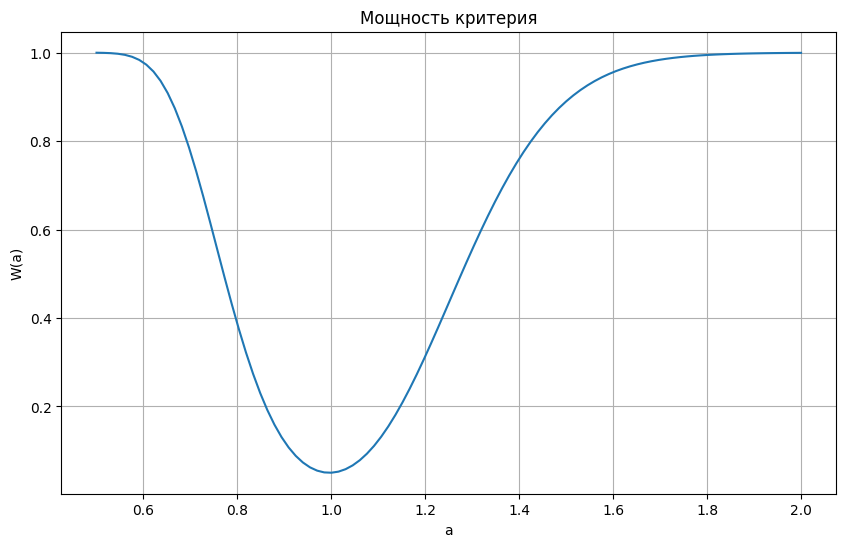

In [8]:
#построение графика мощности критерия
_, axs = plt.subplots(1, 1, figsize=(10, 6))

axs.set_title("Мощность критерия")
axs.set_xlabel("a")
axs.set_ylabel("W(a)")

a = np.linspace(0.5, 2, 100)

axs.plot(
    a,
    1 - stats.f.cdf(quantil_1_minus_a_popolam, n - 1, m - 1, scale=a) + stats.f.cdf(quantil_a_popolam, n - 1, m - 1,
    scale=a))

plt.grid(which='major', linewidth=0.8)

plt.show()